# YouTube Video EDA
Fetches transcripts for a list of video IDs and explores the resulting corpus.

In [ ]:
# pip install youtube-transcript-api pandas matplotlib seaborn

In [6]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from youtube_transcript_api import (
    YouTubeTranscriptApi,
    NoTranscriptFound,
    TranscriptsDisabled,
)

# Make the truthcheck package importable from the notebook
sys.path.insert(0, str(Path("final_project").resolve()))

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Configure video list
Add YouTube video IDs or full URLs below.

In [14]:
RAW_VIDEOS = [
    # paste video IDs or full YouTube URLs here
    # "dQw4w9WgXcQ",
    # "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
    'https://www.youtube.com/watch?v=bHIhgxav9LY',
    'https://www.youtube.com/watch?v=OmJ-4B-mS-Y',
    'https://www.youtube.com/watch?v=h6fcK_fRYaI',
    'https://www.youtube.com/watch?v=JQVmkDUkZT4',
    'https://www.youtube.com/watch?v=Yocja_N5s1I',
    #'https://www.youtube.com/watch?v=Lf9Iy1Gh6jw',
    'https://www.youtube.com/watch?v=zBkVCpbNnkU',
    'https://www.youtube.com/watch?v=PSRJfaAYkW4',
    #'https://www.youtube.com/watch?v=Qh2YsEyTAHw',
]

_YT_ID_RE = re.compile(
    r"(?:v=|youtu\.be/|embed/|shorts/)([A-Za-z0-9_-]{11})"
)

def _extract_id(raw: str) -> str:
    m = _YT_ID_RE.search(raw)
    return m.group(1) if m else raw.strip()

VIDEO_IDS = [_extract_id(v) for v in RAW_VIDEOS]
print(f"{len(VIDEO_IDS)} video(s) queued:", VIDEO_IDS)

7 video(s) queued: ['bHIhgxav9LY', 'OmJ-4B-mS-Y', 'h6fcK_fRYaI', 'JQVmkDUkZT4', 'Yocja_N5s1I', 'zBkVCpbNnkU', 'PSRJfaAYkW4']


## 2. Fetch transcripts

In [15]:
# v1.x API: instantiate first, then call .list() / .fetch()
_api = YouTubeTranscriptApi()

def fetch_transcript(video_id: str) -> list:
    """Return transcript snippets for a video, preferring English."""
    try:
        tlist = _api.list(video_id)
        try:
            t = tlist.find_manually_created_transcript(["en"])
        except Exception:
            t = tlist.find_generated_transcript(["en"])
        return t.fetch()
    except (NoTranscriptFound, TranscriptsDisabled) as e:
        print(f"  [{video_id}] skipped — {e}")
        return []


records = []
for vid in VIDEO_IDS:
    print(f"Fetching {vid} …")
    segs = fetch_transcript(vid)
    for seg in segs:
        # v1.x segments are dataclass objects: seg.text, seg.start, seg.duration
        records.append({
            "video_id": vid,
            "start": seg.start,
            "duration": seg.duration,
            "text": seg.text.strip(),
        })

segments = pd.DataFrame(records)
print(f"\n{len(segments):,} segments across {segments['video_id'].nunique()} video(s)")
segments.head()

Fetching bHIhgxav9LY …
Fetching OmJ-4B-mS-Y …
Fetching h6fcK_fRYaI …
Fetching JQVmkDUkZT4 …
Fetching Yocja_N5s1I …
Fetching zBkVCpbNnkU …
Fetching PSRJfaAYkW4 …

1,723 segments across 7 video(s)


,video_id,start,duration,text
0,bHIhgxav9LY,0.180,2.743,This video was sponsored\nby Caséta by Lutron.
1,bHIhgxav9LY,3.857,2.383,Imagine you have a giant circuit
2,bHIhgxav9LY,6.240,3.010,"consisting of a battery,\na switch, a light bulb,"
3,bHIhgxav9LY,9.250,4.710,"and two wires which are each\n300,000 kilomete..."
4,bHIhgxav9LY,13.960,2.990,That is the distance light\ntravels in one sec...


## 3. Per-video summary

In [16]:
segments["word_count"] = segments["text"].str.split().str.len()

summary = (
    segments.groupby("video_id")
    .agg(
        segments=("text", "count"),
        total_words=("word_count", "sum"),
        duration_s=("duration", "sum"),
        full_text=("text", lambda x: " ".join(x)),
    )
    .assign(
        duration_min=lambda df: (df["duration_s"] / 60).round(1),
        words_per_min=lambda df: (df["total_words"] / (df["duration_s"] / 60)).round(1),
    )
    .drop(columns="duration_s")
)

summary

,segments,total_words,full_text,duration_min,words_per_min
video_id,,,,,
JQVmkDUkZT4,83,979,"Are you your body? Well, kind of, right? But i...",5.7,171.8
OmJ-4B-mS-Y,161,1853,The mathematics we learn in school doesn’t\nqu...,11.1,167.6
PSRJfaAYkW4,90,722,"A mosquito lands on your arm, injects its chem...",5.0,144.9
Yocja_N5s1I,178,2260,"Hello, learned and astonishingly attractive\np...",11.2,202.3
bHIhgxav9LY,374,2460,This video was sponsored\nby Caséta by Lutron....,14.4,170.7
h6fcK_fRYaI,156,910,you were on your way home when you died it was...,15.1,60.1
zBkVCpbNnkU,681,5949,Vaccines are celebrated\nfor their part in fig...,38.4,155.1


## 4. Distributions

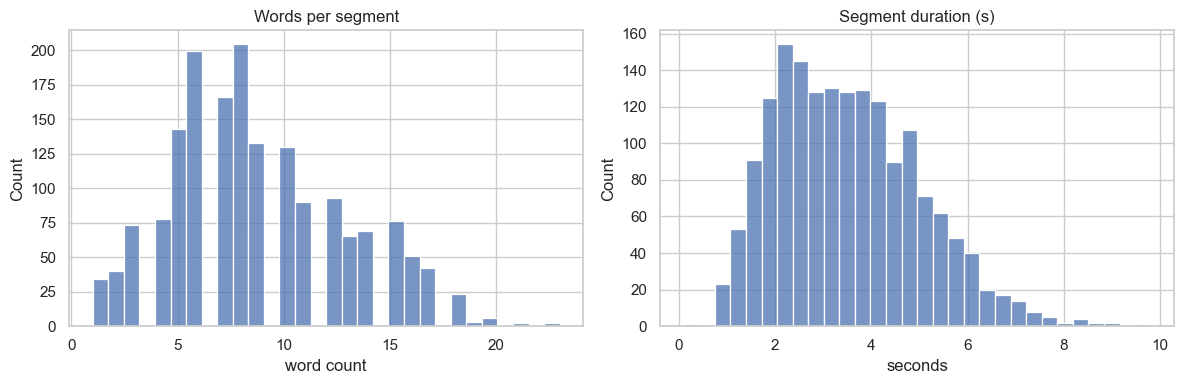

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(segments["word_count"], bins=30, ax=axes[0])
axes[0].set(title="Words per segment", xlabel="word count")

sns.histplot(segments["duration"], bins=30, ax=axes[1])
axes[1].set(title="Segment duration (s)", xlabel="seconds")

plt.tight_layout()

## 5. Segment-level timeline (one video)

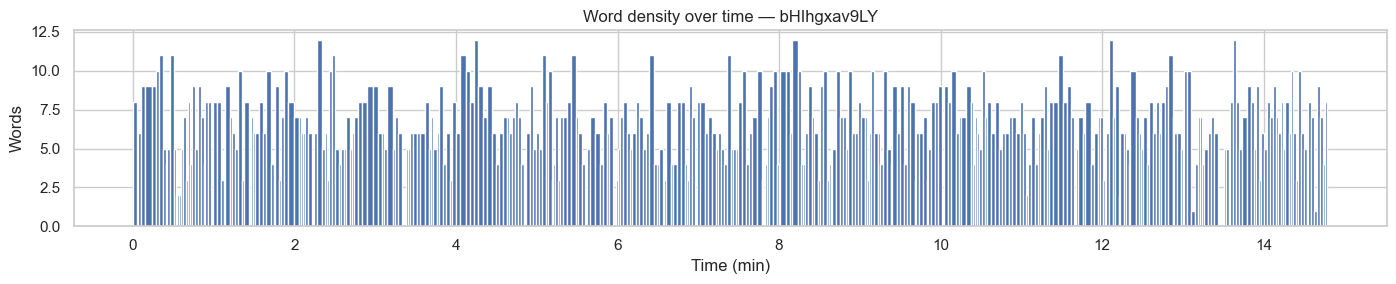

In [18]:
if VIDEO_IDS:
    vid = VIDEO_IDS[0]
    sub = segments[segments["video_id"] == vid].copy()
    sub["start_min"] = sub["start"] / 60

    plt.figure(figsize=(14, 3))
    plt.bar(sub["start_min"], sub["word_count"], width=sub["duration"] / 60, align="edge")
    plt.xlabel("Time (min)")
    plt.ylabel("Words")
    plt.title(f"Word density over time — {vid}")
    plt.tight_layout()

## 6. Quick text inspection

In [19]:
if VIDEO_IDS:
    vid = VIDEO_IDS[0]
    text = summary.loc[vid, "full_text"]
    print(f"--- {vid} (first 2000 chars) ---")
    print(text[:2000])

--- bHIhgxav9LY (first 2000 chars) ---
This video was sponsored
by Caséta by Lutron. Imagine you have a giant circuit consisting of a battery,
a switch, a light bulb, and two wires which are each
300,000 kilometers long. That is the distance light
travels in one second. So, they would reach
out half way to the moon and then come back to be
connected to the light bulb, which is one meter away. Now, the question is, after I close this switch, how long would it take
for the bulb to light up. Is it half a second, one second, two seconds, 1/c seconds, or none of the above. You have to make some
simplifying assumptions about this circuit, like the wires have to have no resistance, otherwise this wouldn't work and the light bulb has
to turn on immediately when current passes through it. But I want you to commit to an answer and put it down in the comments so you can't say, oh yeah I knew that was the answer, when I tell you the answer later on. This question actually relates
to how electrical